In [8]:
import sqlite3
import pandas as pd

In [4]:
con = sqlite3.connect("tutorial.db")


In [6]:
cur = con.cursor()
cur.execute("CREATE TABLE movie(title, year, score)")

OperationalError: table movie already exists

In [7]:
cur = con.cursor()
res = cur.execute("SELECT name FROM sqlite_master")
res.fetchone()

('movie',)

In [10]:
df = pd.read_csv("marketing_campaign_dataset.csv")
df.head()

,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date
0,1,Innovate Industries,Email,Men 18-24,30 days,Google Ads,0.04,"$16,174.00",6.29,Chicago,Spanish,506,1922,6,Health & Wellness,2021-01-01
1,2,NexGen Systems,Email,Women 35-44,60 days,Google Ads,0.12,"$11,566.00",5.61,New York,German,116,7523,7,Fashionistas,2021-01-02
2,3,Alpha Innovations,Influencer,Men 25-34,30 days,YouTube,0.07,"$10,200.00",7.18,Los Angeles,French,584,7698,1,Outdoor Adventurers,2021-01-03
3,4,DataTech Solutions,Display,All Ages,60 days,YouTube,0.11,"$12,724.00",5.55,Miami,Mandarin,217,1820,7,Health & Wellness,2021-01-04
4,5,NexGen Systems,Email,Men 25-34,15 days,YouTube,0.05,"$16,452.00",6.50,Los Angeles,Mandarin,379,4201,3,Health & Wellness,2021-01-05


In [12]:
con = sqlite3.connect("tutorial1.db")
df.to_sql(name="campaigns",con=con, if_exists="replace",index=True)


200000

In [ ]:
con.close()
new_con = sqlite3.connect("tutorial1.db")
new_cur = new_con.cursor()
res = new_cur.execute("SELECT DISTINCT Company FROM campaigns WHERE Campaign_Type is 'Email'")
print(res.fetchall())
new_con.close()




[('Innovate Industries',), ('NexGen Systems',), ('TechCorp',), ('Alpha Innovations',), ('DataTech Solutions',)]


In [ ]:
from langchain_community.utilities import SQLDatabase



In [46]:
db = SQLDatabase.from_uri("sqlite:///tutorial1.db")
print(db.dialect)
print(db.get_usable_table_names())
db.run("SELECT DISTINCT Company FROM campaigns WHERE Campaign_Type is 'Email'")
db.run("SELECT Company, SUM(CAST(SUBSTR(Acquisition_Cost, 2) AS REAL)) AS Total_Acquisition_Cost FROM campaigns GROUP BY Company ORDER BY Total_Acquisition_Cost DESC LIMIT 5;")

sqlite
['campaigns']


"[('TechCorp', 483185.0), ('Alpha Innovations', 481292.0), ('DataTech Solutions', 480370.0), ('NexGen Systems', 479728.0), ('Innovate Industries', 476497.0)]"

## Chains

In [28]:
from typing_extensions import TypedDict


class State(TypedDict):
    question: str
    query: str
    result: str
    answer: str

##  Convert question to SQL query

In [42]:
import getpass
import os

os.environ["OPENAI_API_KEY"] = getpass.getpass()

from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o-mini")

In [43]:
from langchain import hub

query_prompt_template = hub.pull("langchain-ai/sql-query-system-prompt")

assert len(query_prompt_template.messages) == 1
query_prompt_template.messages[0].pretty_print()

/Users/sergiovillegas/Documents/python-projects/analyst_helper/analyst_helper_env/lib/python3.10/site-packages/langsmith/client.py:241: LangSmithMissingAPIKeyWarning: API key must be provided when using hosted LangSmith API
  warnings.warn(


================================ System Message ================================

Given an input question, create a syntactically correct {dialect} query to run to help find the answer. Unless the user specifies in his question a specific number of examples they wish to obtain, always limit your query to at most {top_k} results. You can order the results by a relevant column to return the most interesting examples in the database.

Never query for all the columns from a specific table, only ask for a the few relevant columns given the question.

Pay attention to use only the column names that you can see in the schema description. Be careful to not query for columns that do not exist. Also, pay attention to which column is in which table.

Only use the following tables:
{table_info}

Question: {input}


In [44]:
from typing_extensions import Annotated


class QueryOutput(TypedDict):
    """Generated SQL query."""

    query: Annotated[str, ..., "Syntactically valid SQL query."]


def write_query(state: State):
    """Generate SQL query to fetch information."""
    prompt = query_prompt_template.invoke(
        {
            "dialect": db.dialect,
            "top_k": 10,
            "table_info": db.get_table_info(),
            "input": state["question"],
        }
    )
    structured_llm = llm.with_structured_output(QueryOutput)
    result = structured_llm.invoke(prompt)
    return {"query": result["query"]}

In [45]:
write_query({"question": "What is the top 5 Company by the sum of Acquisition_Cost?"})

{'query': 'SELECT Company, SUM(CAST(SUBSTR(Acquisition_Cost, 2) AS REAL)) AS Total_Acquisition_Cost FROM campaigns GROUP BY Company ORDER BY Total_Acquisition_Cost DESC LIMIT 5;'}

In [47]:
from langchain_community.tools.sql_database.tool import QuerySQLDataBaseTool


def execute_query(state: State):
    """Execute SQL query."""
    execute_query_tool = QuerySQLDataBaseTool(db=db)
    return {"result": execute_query_tool.invoke(state["query"])}

In [49]:
execute_query({"query": "SELECT Company, SUM(CAST(SUBSTR(Acquisition_Cost, 2) AS REAL)) AS Total_Acquisition_Cost FROM campaigns GROUP BY Company ORDER BY Total_Acquisition_Cost DESC LIMIT 5;"})

{'result': "[('TechCorp', 483185.0), ('Alpha Innovations', 481292.0), ('DataTech Solutions', 480370.0), ('NexGen Systems', 479728.0), ('Innovate Industries', 476497.0)]"}

In [51]:
def generate_answer(state: State):
    """Answer question using retrieved information as context."""
    prompt = (
        "Given the following user question, corresponding SQL query, "
        "and SQL result, answer the user question.\n\n"
        f'Question: {state["question"]}\n'
        f'SQL Query: {state["query"]}\n'
        f'SQL Result: {state["result"]}'
    )
    response = llm.invoke(prompt)
    return {"answer": response.content}

In [52]:
from langgraph.graph import START, StateGraph

graph_builder = StateGraph(State).add_sequence(
    [write_query, execute_query, generate_answer]
)
graph_builder.add_edge(START, "write_query")
graph = graph_builder.compile() 

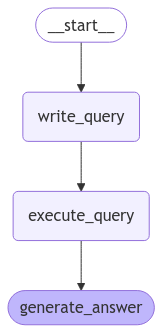

In [53]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [54]:
for step in graph.stream(
    {"question": "What is the top 5 Company by the sum of Acquisition_Cost?"}, stream_mode="updates"
):
    print(step)

{'write_query': {'query': "SELECT Company, SUM(REPLACE(Acquisition_Cost, '$', '')) AS Total_Acquisition_Cost \nFROM campaigns \nGROUP BY Company \nORDER BY Total_Acquisition_Cost DESC \nLIMIT 5;"}}
{'execute_query': {'result': "[('TechCorp', 483185.0), ('Alpha Innovations', 481292.0), ('DataTech Solutions', 480370.0), ('NexGen Systems', 479728.0), ('Innovate Industries', 476497.0)]"}}
{'generate_answer': {'answer': 'The top 5 companies by the sum of Acquisition Cost are:\n\n1. TechCorp - $483,185.00\n2. Alpha Innovations - $481,292.00\n3. DataTech Solutions - $480,370.00\n4. NexGen Systems - $479,728.00\n5. Innovate Industries - $476,497.00'}}


In [65]:
for step in graph.stream(
    {"question": "What is the monthly CTR (Clicks / Impressions)* in 2021 for Company which Engagement_Score is greater than 7? group by months"}, stream_mode="updates"
):
     print(step)

{'write_query': {'query': "SELECT Company, (Clicks * 1.0 / Impressions) AS CTR, strftime('%Y-%m', Date) AS Month \nFROM campaigns \nWHERE Engagement_Score > 7 AND Date LIKE '2021%'\nGROUP BY Month, Company \nORDER BY Month \nLIMIT 10;"}}
{'execute_query': {'result': "[('Alpha Innovations', 0.02353195164075993, '2021-01'), ('DataTech Solutions', 0.058475012879958786, '2021-01'), ('Innovate Industries', 0.354195642095503, '2021-01'), ('NexGen Systems', 0.09338210081152132, '2021-01'), ('TechCorp', 0.07678348644663718, '2021-01'), ('Alpha Innovations', 0.059845559845559844, '2021-02'), ('DataTech Solutions', 0.5290836653386454, '2021-02'), ('Innovate Industries', 0.08524355300859598, '2021-02'), ('NexGen Systems', 0.11404599129894344, '2021-02'), ('TechCorp', 0.020333468889792598, '2021-02')]"}}
{'generate_answer': {'answer': 'The monthly Click-Through Rate (CTR) for companies with an Engagement Score greater than 7 in 2021 is as follows:\n\n- January 2021:\n  - Alpha Innovations: 0.0235\

In [63]:
df.groupby("Company").sum("ROI")

,Campaign_ID,Conversion_Rate,ROI,Clicks,Impressions,Engagement_Score
Company,,,,,,
Alpha Innovations,3990925450,3207.44,200493.05,21983300,220640249,220162
DataTech Solutions,4003994190,3200.51,200281.55,22041615,220252334,220123
Innovate Industries,3984448072,3191.98,198631.37,21805668,218725247,218714
NexGen Systems,4007806242,3188.73,199609.18,21957338,220336917,219634
TechCorp,4012926046,3225.27,201472.42,22166485,221505557,220309
